In [1]:
import jax
import jax.numpy as jnp
import equinox as eqx
from jaxtyping import Float, Array, PRNGKeyArray
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

In [2]:
class TruncatedFourier1D(eqx.Module):
    an: Float[Array, " K"]
    bn: Float[Array, " K"]
    a0: Float[Array, ""] = eqx.field(default_factory=lambda: jnp.array(0.0))
    L: float = eqx.field(static=True, default=1.0)

    def __call__(self, x: Float[Array, " *shape"]):
        kx: Float[Array, "*shape K"] = jnp.expand_dims(x, axis=-1) * self.wavenumbers
        cos_kx, sin_kx = jnp.cos(kx), jnp.sin(kx)
        return self.a0 + jnp.mean(
            self.an * cos_kx + self.bn * sin_kx, axis=-1
        ) / jnp.sqrt(2)

    @property
    def num_modes(self) -> int:
        return len(self.an)

    @property
    def wavenumbers(self) -> Float[Array, " K"]:
        return jnp.arange(1, self.num_modes + 1) * 2 * jnp.pi / self.L

    @classmethod
    def with_uniform_rand_coeffs(
        cls,
        num_modes: int,
        L: float = 1.0,
        coeff_range: tuple[float, float] = (1, 1),
        offset_range: tuple[float, float] | None = None,
        *,
        key: PRNGKeyArray = jax.random.PRNGKey(0),
    ):
        key_coeff, key_offset = jax.random.split(key, 2)
        an_bn = jax.random.uniform(
            key_coeff,
            shape=(2, num_modes),
            minval=coeff_range[0],
            maxval=coeff_range[1],
        )
        if offset_range is None:
            a0 = jnp.array(0.0)
        else:
            a0 = jax.random.uniform(
                key_offset, minval=offset_range[0], maxval=offset_range[1]
            )
        return cls(*an_bn, a0, L)

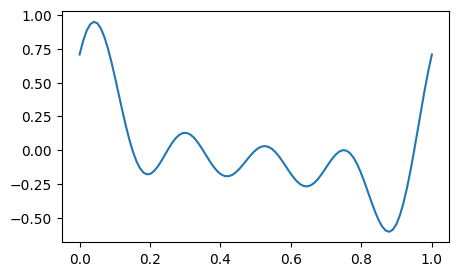

In [3]:
u0 = TruncatedFourier1D.with_uniform_rand_coeffs(num_modes=4)
x = jnp.linspace(0, 1, 100)
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x, u0(x))

In [4]:
from clawpack import pyclaw, riemann

riemann_solver = riemann.burgers_1D
solver = pyclaw.ClawSolver1D(riemann_solver)
solver.limiters = pyclaw.limiters.tvd.vanleer
solver.bc_lower[0] = pyclaw.BC.periodic
solver.bc_upper[0] = pyclaw.BC.periodic


In [5]:
from typing import Any
from collections.abc import Callable


class PDEProblem1D:
    pde: Any
    domain: Any
    bc: Any
    ic_factory: Callable

    def __init__(self, pde, x_min, x_max, Nx, bc):
        self.pde = pde


In [6]:
x = pyclaw.Dimension(0.0, 1.0, 1024, name="x")
domain = pyclaw.Domain(x)
state = pyclaw.State(domain, solver.num_eqn)

xc = state.grid.x.centers
state.q[0, :] = u0(xc)
state.problem_data["efix"] = True

solution = pyclaw.Solution(state, domain)

controller = pyclaw.Controller()
controller.outdir = "./temp/"
controller.solver = solver
controller.solution = solution
controller.tfinal = 0.6
controller.num_output_times = 1000
controller.keep_copy = True
controller.output_style = 1
controller.output_format = "ascii"

In [7]:
status = controller.run()

2025-08-08 17:16:01,767 INFO CLAW: Solution 0 computed for time t=0.000000
2025-08-08 17:16:01,776 INFO CLAW: Solution 1 computed for time t=0.000600
2025-08-08 17:16:01,783 INFO CLAW: Solution 2 computed for time t=0.001200
2025-08-08 17:16:01,792 INFO CLAW: Solution 3 computed for time t=0.001800
2025-08-08 17:16:01,799 INFO CLAW: Solution 4 computed for time t=0.002400
2025-08-08 17:16:01,807 INFO CLAW: Solution 5 computed for time t=0.003000
2025-08-08 17:16:01,814 INFO CLAW: Solution 6 computed for time t=0.003600
2025-08-08 17:16:01,821 INFO CLAW: Solution 7 computed for time t=0.004200
2025-08-08 17:16:01,828 INFO CLAW: Solution 8 computed for time t=0.004800
2025-08-08 17:16:01,836 INFO CLAW: Solution 9 computed for time t=0.005400
2025-08-08 17:16:01,843 INFO CLAW: Solution 10 computed for time t=0.006000
2025-08-08 17:16:01,850 INFO CLAW: Solution 11 computed for time t=0.006600
2025-08-08 17:16:01,857 INFO CLAW: Solution 12 computed for time t=0.007200
2025-08-08 17:16:01,86

In [8]:
solution.__dict__

{'claw_package': <module 'clawpack.pyclaw' from '/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/clawpack/pyclaw/__init__.py'>,
 'states': [<clawpack.pyclaw.state.State at 0x14cf7415e750>],
 'domain': <clawpack.pyclaw.geometry.Domain at 0x14cfc80f4380>,
 '_start_frame': 1001}

In [25]:
import numpy as np

sol = np.expand_dims(np.stack([f.state.q for f in controller.frames], axis=0), axis=0)

sol.shape

(1, 1001, 1, 1024)

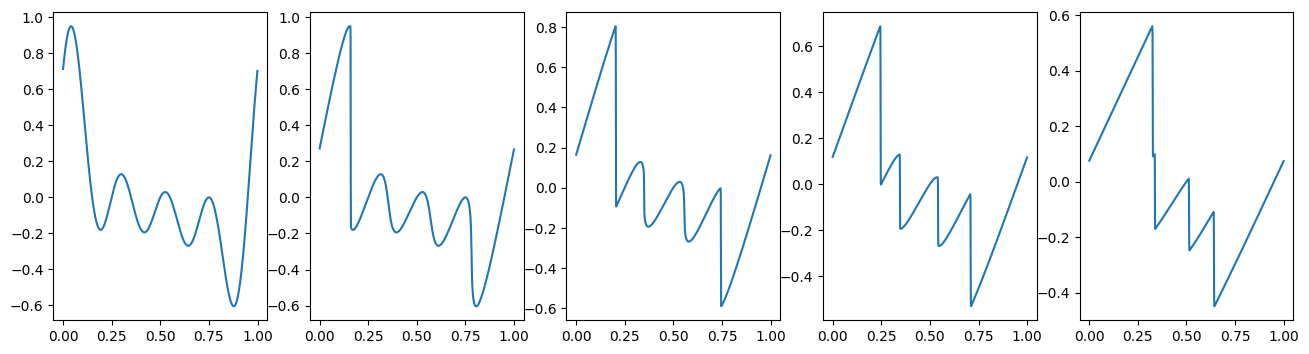

In [10]:
t_vals = (0, 200, 400, 600, 1000)
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharex=True)
for j, t_i in enumerate(t_vals):
    axes[j].plot(xc, sol[t_i, 0])

In [29]:
import xarray as xr

time = np.linspace(0, controller.tfinal, controller.num_output_times + 1, endpoint=True)
x_grid = xc
dim = ["u"]

data_array = xr.DataArray(
    sol,
    coords={"t": time, "x": x_grid, "dim": dim, "nu": ("sample", [0.0])},
    dims=["sample", "t", "dim", "x"],
)

In [30]:
data_array

<xarray.DataArray (sample: 1, t: 1001, dim: 1, x: 1024)> Size: 8MB
array([[[[0.71250518, 0.7231502 , 0.73358954, ..., 0.67937639,
          0.69061415, 0.70165847]],

        [[0.70781315, 0.7184767 , 0.72894027, ..., 0.67466297,
          0.68590216, 0.69695361]],

        [[0.70314593, 0.71382476, 0.72430918, ..., 0.66998341,
          0.68122115, 0.69227671]],

        ...,

        [[0.07582843, 0.07729656, 0.07876473, ..., 0.07142431,
          0.07289231, 0.07436035]],

        [[0.0757601 , 0.0772269 , 0.07869374, ..., 0.07135995,
          0.07282662, 0.07429334]],

        [[0.07569188, 0.07715736, 0.07862289, ..., 0.0712957 ,
          0.07276105, 0.07422645]]]], shape=(1, 1001, 1, 1024))
Coordinates:
  * t        (t) float64 8kB 0.0 0.0006 0.0012 0.0018 ... 0.5988 0.5994 0.6
  * x        (x) float64 8kB 0.0004883 0.001465 0.002441 ... 0.9985 0.9995
  * dim      (dim) <U1 4B 'u'
    nu       (sample) float64 8B 0.0
Dimensions without coordinates: sample

In [31]:
xr.concat((data_array, data_array), "sample")

<xarray.DataArray (sample: 2, t: 1001, dim: 1, x: 1024)> Size: 16MB
array([[[[0.71250518, 0.7231502 , 0.73358954, ..., 0.67937639,
          0.69061415, 0.70165847]],

        [[0.70781315, 0.7184767 , 0.72894027, ..., 0.67466297,
          0.68590216, 0.69695361]],

        [[0.70314593, 0.71382476, 0.72430918, ..., 0.66998341,
          0.68122115, 0.69227671]],

        ...,

        [[0.07582843, 0.07729656, 0.07876473, ..., 0.07142431,
          0.07289231, 0.07436035]],

        [[0.0757601 , 0.0772269 , 0.07869374, ..., 0.07135995,
          0.07282662, 0.07429334]],

        [[0.07569188, 0.07715736, 0.07862289, ..., 0.0712957 ,
          0.07276105, 0.07422645]]],


       [[[0.71250518, 0.7231502 , 0.73358954, ..., 0.67937639,
          0.69061415, 0.70165847]],

        [[0.70781315, 0.7184767 , 0.72894027, ..., 0.67466297,
          0.68590216, 0.69695361]],

        [[0.70314593, 0.71382476, 0.72430918, ..., 0.66998341,
          0.68122115, 0.69227671]],

        ...,

        [[0.07582843, 0.07729656, 0.07876473, ..., 0.07142431,
          0.07289231, 0.07436035]],

        [[0.0757601 , 0.0772269 , 0.07869374, ..., 0.07135995,
          0.07282662, 0.07429334]],

        [[0.07569188, 0.07715736, 0.07862289, ..., 0.0712957 ,
          0.07276105, 0.07422645]]]], shape=(2, 1001, 1, 1024))
Coordinates:
  * t        (t) float64 8kB 0.0 0.0006 0.0012 0.0018 ... 0.5988 0.5994 0.6
  * x        (x) float64 8kB 0.0004883 0.001465 0.002441 ... 0.9985 0.9995
  * dim      (dim) <U1 4B 'u'
    nu       (sample) float64 16B 0.0 0.0
Dimensions without coordinates: sample

In [37]:
data_array.coords["nu"].dims

('sample',)

In [12]:
from context_flux_no.models.fno import FNO1D

fno = FNO1D(
    data_dim=1, lift_dim=64, depth=4, frequency_modes=8, key=jax.random.PRNGKey(0)
)


In [13]:
out = fno(sol[0])

2025-07-29 01:36:37.117089: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1,64,1024]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.2), window={size=1}, dim_labels=bf0_oi0->bf0, custom_call_target="__cudnn$convForward", metadata={op_name="jit(conv_general_dilated)/jit(main)/conv_general_dilated" source_file="/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/equinox/nn/_conv.py" source_line=238}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-07-29 01:36:40.975288: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.858323399s
Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1,64,1024]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.2), 

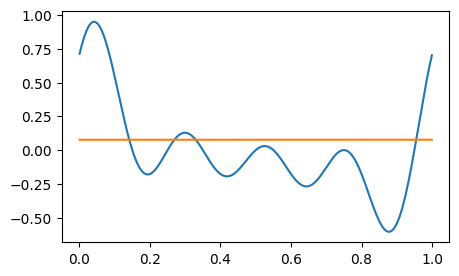

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(xc, sol[0][0])
ax.plot(xc, out[0])

In [15]:
sol[1:501].shape

(500, 1, 1024)

In [16]:
import optax


@eqx.filter_value_and_grad
def loss_fn(model, u0, u1):
    u1_pred = eqx.filter_vmap(model)(u0)
    return jnp.mean((u1_pred - u1) ** 2)


optim = optax.adabelief(learning_rate=1e-3)
opt_state = optim.init(eqx.filter(fno, eqx.is_array))


@eqx.filter_jit
def make_step(model, u0, u1, opt_state):
    loss, grads = loss_fn(model, u0, u1)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


In [22]:
max_epochs = 500
loss_history = []
for i in range(max_epochs):
    fno, opt_state, loss = make_step(fno, sol[0:300], sol[1:301], opt_state)
    loss_history.append(loss)
    print(f"Epoch = {i}: Loss = {loss.item()}")

Epoch = 0: Loss = 0.00020421074658257243
Epoch = 1: Loss = 0.00014109168473465345
Epoch = 2: Loss = 0.0001617548698729333
Epoch = 3: Loss = 0.0001677714428678142
Epoch = 4: Loss = 0.00012144901944100197
Epoch = 5: Loss = 0.00016602083143685232
Epoch = 6: Loss = 0.0001357075982198397
Epoch = 7: Loss = 0.00013018305315784629
Epoch = 8: Loss = 0.00014964680985533993
Epoch = 9: Loss = 0.00012164262753276757
Epoch = 10: Loss = 0.00013917721858387248
Epoch = 11: Loss = 0.00013439717139500522
Epoch = 12: Loss = 0.00011805309309739107
Epoch = 13: Loss = 0.0001374891835581763
Epoch = 14: Loss = 0.0001241620070103194
Epoch = 15: Loss = 0.0001221958545635538
Epoch = 16: Loss = 0.00013080572037865317
Epoch = 17: Loss = 0.00011635836484363279
Epoch = 18: Loss = 0.00012365914155873433
Epoch = 19: Loss = 0.00012510949754455044
Epoch = 20: Loss = 0.0001159500258631523
Epoch = 21: Loss = 0.0001224002390939585
Epoch = 22: Loss = 0.00011942344283503516
Epoch = 23: Loss = 0.00011550717089296924
Epoch = 24

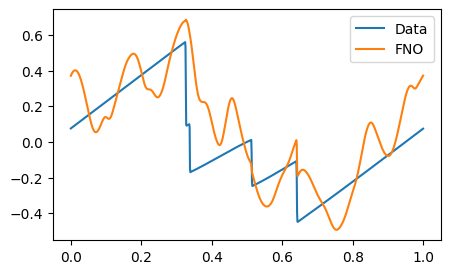

In [24]:
time_idx = 999
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(xc, sol[time_idx + 1][0], label="Data")
ax.plot(xc, fno(sol[time_idx])[0], label="FNO")
ax.legend()

In [20]:
sol[time_idx][0:1].shape

(1, 1024)

In [ ]:
from context_flux_no.nn.fourier import SpectralConv1D
from context_flux_no.nn.fourier import SpectralConv1D as SpectralConv1D_new

time_idx = 1000
conv1 = SpectralConv1D(1, 32, 15, key=jax.random.key(0))
conv2 = SpectralConv1D_new(1, 32, 15, key=jax.random.key(0))

jnp.max(conv1(sol[time_idx][0:1]))

Array(0.0183449, dtype=float64)

In [21]:
jnp.max(conv2(sol[time_idx][0:1]))

out_fft_shape_new=(Array(32, dtype=int64, weak_type=True), Array(513, dtype=int64, weak_type=True))


Array(0.0183449, dtype=float64)

In [20]:
jnp.all(conv1(sol[time_idx][0:1]) == conv2(sol[time_idx][0:1]))

out_fft_shape_new=(Array(32, dtype=int64, weak_type=True), Array(513, dtype=int64, weak_type=True))


Array(True, dtype=bool)

In [21]:
jnp.all(
    jax.grad(lambda x: jnp.mean(conv1(x)))(sol[time_idx][0:1])
    == jax.grad(lambda x: jnp.mean(conv2(x)))(sol[time_idx][0:1])
)

out_fft_shape_new=(Array(32, dtype=int64, weak_type=True), Array(513, dtype=int64, weak_type=True))


Array(True, dtype=bool)